## Cargar clima

Leemos `clima_limpio.csv` y convertimos `TW` a fecha. Mostramos las primeras filas para ver columnas y formato.

In [2]:
import pandas as pd
from pathlib import Path

# Ruta al archivo accidentes.csv
RUTA_CLIMA = Path("../Datos/Staging/clima_limpio.csv")

# Leer el CSV
clima = pd.read_csv(RUTA_CLIMA, parse_dates=["TW"])

# Mostrar primeras 5 filas
clima.head()

,TW,BARRIO,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,1.02,90.0,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099


## Cargar Accidentes

Leemos `accidentes.csv` y convertimos `TW` a fecha. Mostramos las primeras filas para ver columnas y formato.

In [3]:
import pandas as pd
from pathlib import Path

# Ruta al archivo accidentes.csv
RUTA_ACCIDENTES = Path("../Datos/Raw/accidentes.csv")

# Leer el CSV
accidentes = pd.read_csv(RUTA_ACCIDENTES, parse_dates=["TW"])

# Mostrar primeras 5 filas
accidentes.head()

,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570146,JUEVES,7,20,8
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600280,JUEVES,6,15,16
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584306,DOMINGO,7,2,16
3,2017-03-29 18:00:00,losconquistadores,6.239497,-75.583062,MIERCOLES,3,29,18
4,2017-07-26 20:00:00,cuartabrigada,6.260463,-75.590193,MIERCOLES,7,26,20


## Cargar accidentes

Leemos `accidentes.csv` (datos crudos) con la misma clave temporal `TW` y el barrio.

In [4]:
import pandas as pd
LLAVES = ["BARRIO", "TW"]
accidentes_target = (
    accidentes[LLAVES]
    .drop_duplicates()
    .copy()
)

In [5]:
accidentes_target["target"] = 1

print("Columnas de accidentes_target:")
print(accidentes_target.columns.tolist())

display(accidentes_target.head())

Columnas de accidentes_target:
['BARRIO', 'TW', 'target']


,BARRIO,TW,target
0,sandiego,2017-07-20 08:00:00,1
1,lasacacias,2017-06-15 16:00:00,1
2,lopezdemesa,2017-07-02 16:00:00,1
3,losconquistadores,2017-03-29 18:00:00,1
4,cuartabrigada,2017-07-26 20:00:00,1


## Claves únicas de accidente

Definimos las llaves de cruce (`BARRIO`, `TW`) y dejamos una fila por cada combinación única en accidentes (`accidentes_target`).

In [6]:

print(f"Filas en clima: {len(clima):,}")
print(f"Filas en accidentes original: {len(accidentes):,}")
print(f"Parejas únicas BARRIO + TW con accidente: {len(accidentes_target):,}")

duplicados_acc = accidentes.duplicated(subset=LLAVES).sum()
duplicados_clima = clima.duplicated(subset=LLAVES).sum()

print(f"Duplicados en accidentes por {LLAVES}: {duplicados_acc:,}")
print(f"Duplicados en clima por {LLAVES}: {duplicados_clima:,}")

Filas en clima: 7,436,188
Filas en accidentes original: 120,587
Parejas únicas BARRIO + TW con accidente: 120,587
Duplicados en accidentes por ['BARRIO', 'TW']: 0
Duplicados en clima por ['BARRIO', 'TW']: 0


## Tamaño de tablas y duplicados

Comparamos cuántas filas hay en clima, en accidentes y en claves únicas. Contamos duplicados por `BARRIO` + `TW` en cada tabla.

In [18]:
clima_llaves = clima[LLAVES].drop_duplicates()
validacion_match = accidentes_target.merge(
    clima_llaves,
    on=LLAVES,
    how="left",
    indicator=True
)

resumen_match = validacion_match["_merge"].value_counts().rename_axis("estado").reset_index(name="cantidad")
resumen_match["porcentaje"] = (resumen_match["cantidad"] / len(validacion_match) * 100).round(2)

print("\nAccidentes que cruzan contra clima:")
display(resumen_match)


Accidentes que cruzan contra clima:


,estado,cantidad,porcentaje
0,both,112575,93.36
1,left_only,8012,6.64
2,right_only,0,0.00


In [7]:
df_modelo = clima.merge(
    accidentes_target,
    on=LLAVES,
    how="left",
    validate="many_to_one"
)

In [8]:
df_modelo["target"] = df_modelo["target"].fillna(0).astype(int)

Distribuciòn del Target

In [9]:
distribucion_target = (
    df_modelo["target"]
    .value_counts()
    .sort_index()
    .reset_index()
)
distribucion_target.columns = ["target", "cantidad"]
distribucion_target["porcentaje"] = (
    distribucion_target["cantidad"] / len(df_modelo) * 100
).round(2)

print("\n" + "=" * 70)
print("DISTRIBUCIÓN FINAL DEL TARGET")
print("=" * 70)
display(distribucion_target)

print(f"Total registros dataset final: {len(df_modelo):,}")
print(f"Target = 1, hubo accidente: {df_modelo['target'].sum():,}")
print(f"Target = 0, no hubo accidente: {(df_modelo['target'] == 0).sum():,}")


DISTRIBUCIÓN FINAL DEL TARGET


,target,cantidad,porcentaje
0,0,7323613,98.49
1,1,112575,1.51


Total registros dataset final: 7,436,188
Target = 1, hubo accidente: 112,575
Target = 0, no hubo accidente: 7,323,613


In [24]:
print("\nNaN en target después del fillna:")
print(df_modelo["target"].isna().sum())


NaN en target después del fillna:
0


Se utilizó un LEFT JOIN tomando clima como tabla base, ya que esta tabla contiene las combinaciones barrio-hora sobre las cuales se desea predecir la ocurrencia de accidentes. La tabla accidentes solo contiene los casos positivos, es decir, las parejas (BARRIO, TW) donde ocurrió al menos un accidente. Por tanto, después del cruce, los registros que coinciden con accidentes se marcaron como target = 1, mientras que los registros sin coincidencia quedaron inicialmente como NaN y fueron transformados a target = 0, representando los casos sin accidente registrado. Esta unión permite construir el problema de clasificación binaria requerido.

Variables climáticas encontradas:
['temperature', 'dewPoint', 'humidity', 'precipIntensity', 'precipProbability', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility']

TASA GLOBAL DE ACCIDENTES
Tasa global: 1.5139%
Accidentes por cada 10.000 registros: 151.39

VARIABLE: temperature


,rango_temperature,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(4.5089999999999995, 15.53]",748289,2882,0.003851,745407,0.3851,38.51,0.25,10.06
1,"(15.53, 16.44]",744025,4882,0.006562,739143,0.6562,65.62,0.43,10.01
2,"(16.44, 17.11]",742868,6155,0.008285,736713,0.8285,82.85,0.55,9.99
3,"(17.11, 17.76]",740795,7182,0.009695,733613,0.9695,96.95,0.64,9.96
4,"(17.76, 18.55]",742664,9470,0.012751,733194,1.2751,127.51,0.84,9.99
5,"(18.55, 19.8]",745957,13128,0.017599,732829,1.7599,175.99,1.16,10.03
6,"(19.8, 21.52]",743621,14583,0.019611,729038,1.9611,196.11,1.30,10.00
7,"(21.52, 23.27]",742383,15553,0.020950,726830,2.0950,209.50,1.38,9.98
8,"(23.27, 25.15]",742875,17478,0.023528,725397,2.3528,235.28,1.55,9.99
9,"(25.15, 35.99]",742711,21262,0.028628,721449,2.8628,286.28,1.89,9.99


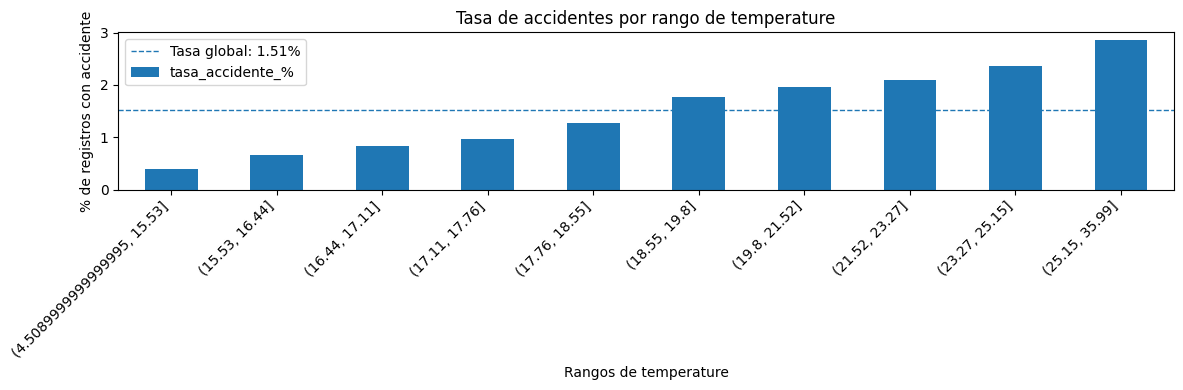

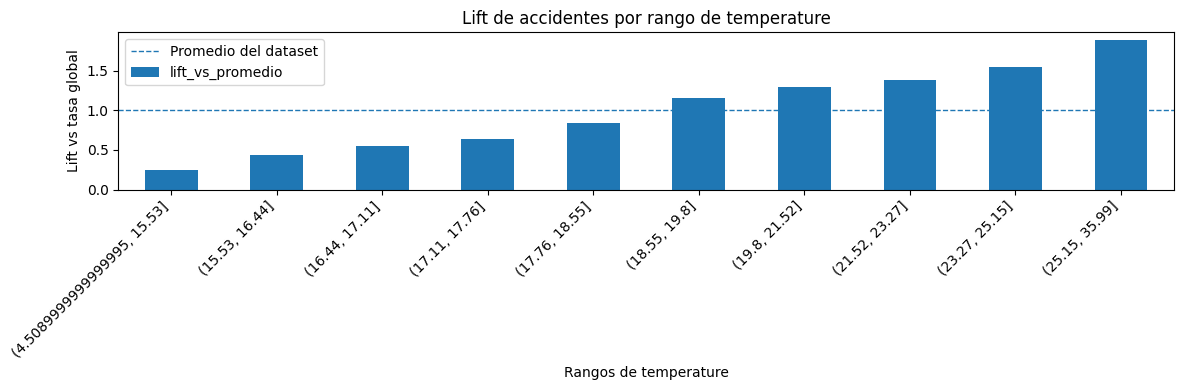


VARIABLE: dewPoint


,rango_dewPoint,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(2.1590000000000003, 11.64]",744249,8086,0.010865,736163,1.0865,108.65,0.72,10.01
1,"(11.64, 12.48]",748064,7951,0.010629,740113,1.0629,106.29,0.70,10.06
2,"(12.48, 13.19]",745916,9899,0.013271,736017,1.3271,132.71,0.88,10.03
3,"(13.19, 13.92]",742510,11053,0.014886,731457,1.4886,148.86,0.98,9.99
4,"(13.92, 14.4]",744459,10458,0.014048,734001,1.4048,140.48,0.93,10.01
5,"(14.4, 14.95]",739251,11117,0.015038,728134,1.5038,150.38,0.99,9.94
6,"(14.95, 15.49]",746811,10763,0.014412,736048,1.4412,144.12,0.95,10.04
7,"(15.49, 16.12]",742225,13272,0.017881,728953,1.7881,178.81,1.18,9.98
8,"(16.12, 16.91]",747985,15371,0.020550,732614,2.0550,205.50,1.36,10.06
9,"(16.91, 24.04]",734718,14605,0.019878,720113,1.9878,198.78,1.31,9.88


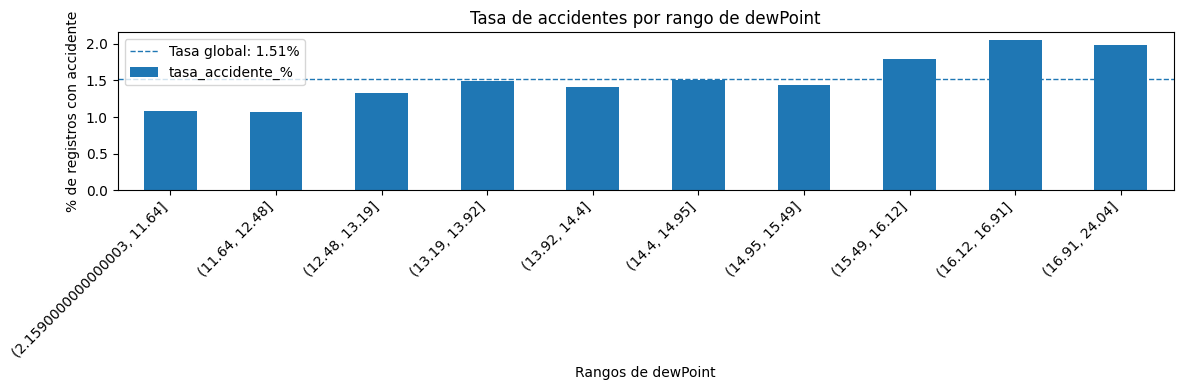

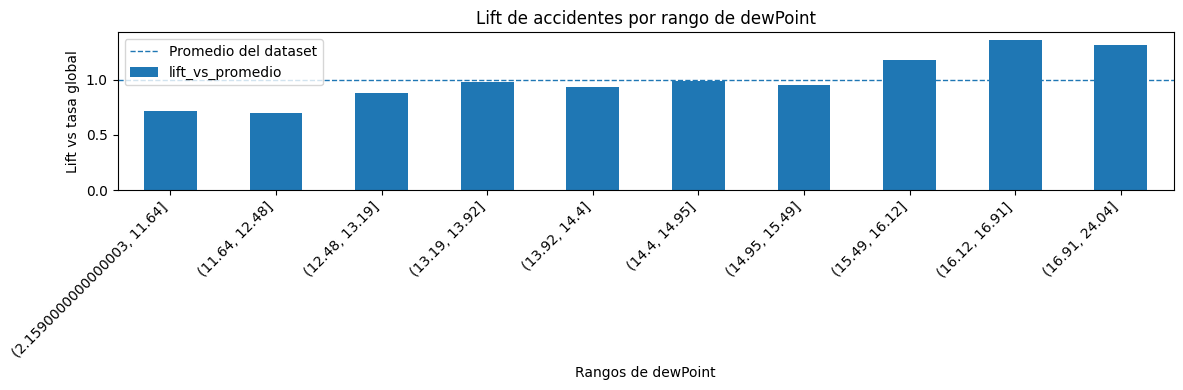


VARIABLE: humidity


,rango_humidity,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(0.169, 0.51]",753479,19739,0.026197,733740,2.6197,261.97,1.73,10.13
1,"(0.51, 0.61]",814102,19204,0.023589,794898,2.3589,235.89,1.56,10.95
2,"(0.61, 0.68]",702725,15076,0.021454,687649,2.1454,214.54,1.42,9.45
3,"(0.68, 0.71]",759104,11628,0.015318,747476,1.5318,153.18,1.01,10.21
4,"(0.71, 0.74]",721265,8621,0.011953,712644,1.1953,119.53,0.79,9.70
5,"(0.74, 0.78]",756583,8530,0.011274,748053,1.1274,112.74,0.74,10.17
6,"(0.78, 0.83]",833519,9757,0.011706,823762,1.1706,117.06,0.77,11.21
7,"(0.83, 0.87]",645527,7903,0.012243,637624,1.2243,122.43,0.81,8.68
8,"(0.87, 0.93]",746730,7854,0.010518,738876,1.0518,105.18,0.69,10.04
9,"(0.93, 1.0]",703154,4263,0.006063,698891,0.6063,60.63,0.40,9.46


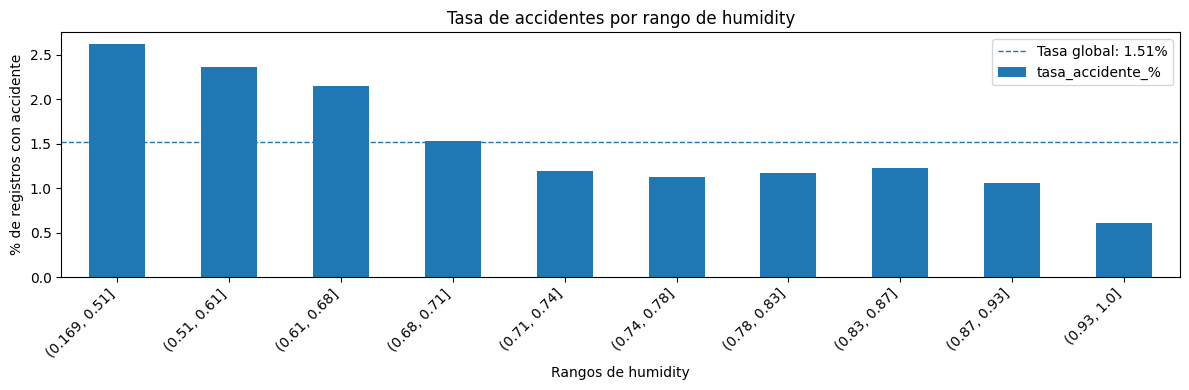

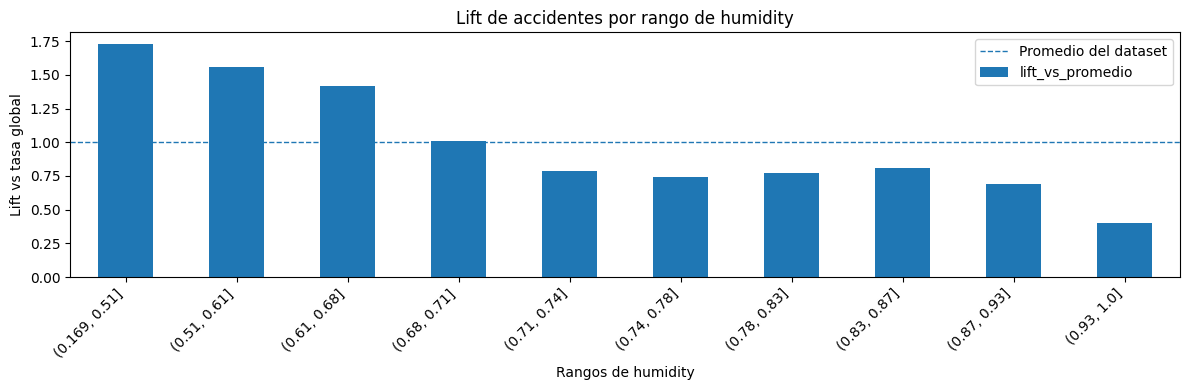


VARIABLE: precipIntensity


,rango_precipIntensity,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(-0.001, 0.0303]",3718577,55434,0.014907,3663143,1.4907,149.07,0.98,50.01
1,"(0.0303, 0.16]",743366,10682,0.014370,732684,1.4370,143.70,0.95,10.00
2,"(0.16, 0.421]",743573,10880,0.014632,732693,1.4632,146.32,0.97,10.00
3,"(0.421, 0.831]",743529,11665,0.015689,731864,1.5689,156.89,1.04,10.00
4,"(0.831, 1.557]",743534,11945,0.016065,731589,1.6065,160.65,1.06,10.00
5,"(1.557, 20.824]",743609,11969,0.016096,731640,1.6096,160.96,1.06,10.00


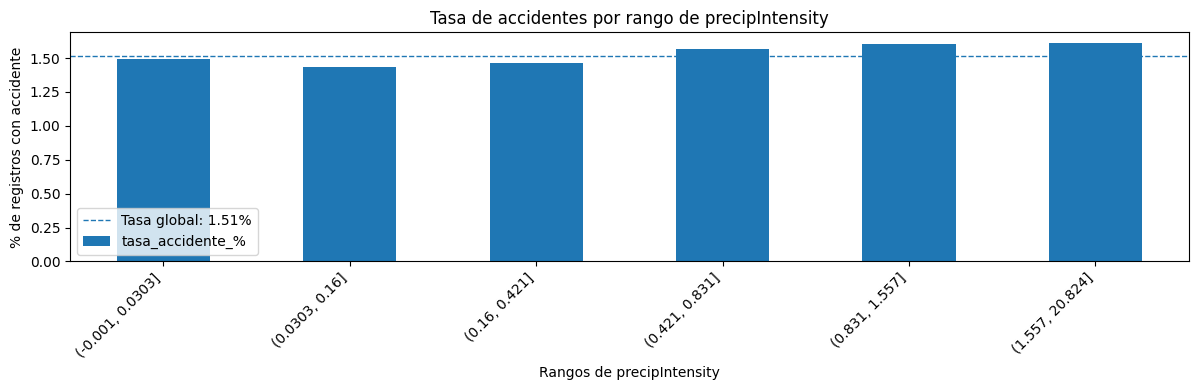

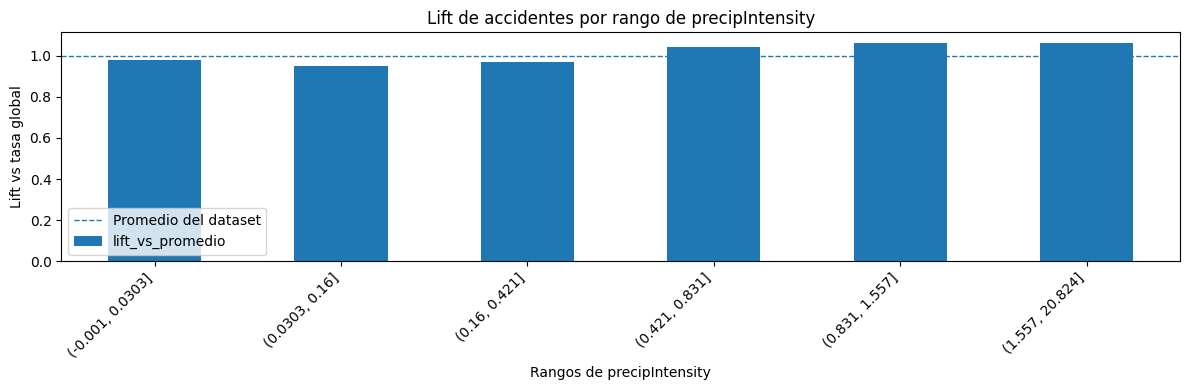


VARIABLE: precipProbability


,rango_precipProbability,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(-0.001, 0.06]",3719493,56023,0.015062,3663470,1.5062,150.62,0.99,50.02
1,"(0.06, 0.14]",795118,12907,0.016233,782211,1.6233,162.33,1.07,10.69
2,"(0.14, 0.22]",713494,11633,0.016304,701861,1.6304,163.04,1.08,9.59
3,"(0.22, 0.31]",791133,13093,0.016550,778040,1.6550,165.50,1.09,10.64
4,"(0.31, 0.43]",706993,10687,0.015116,696306,1.5116,151.16,1.00,9.51
5,"(0.43, 1.0]",709957,8232,0.011595,701725,1.1595,115.95,0.77,9.55


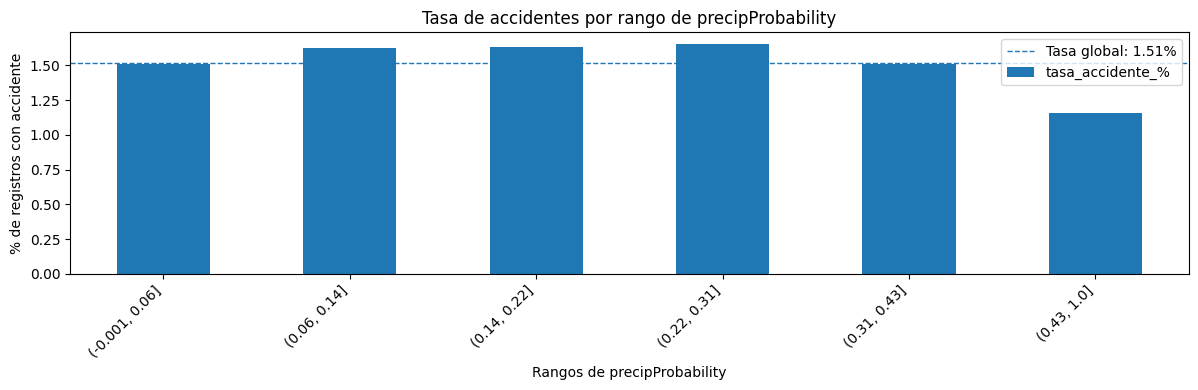

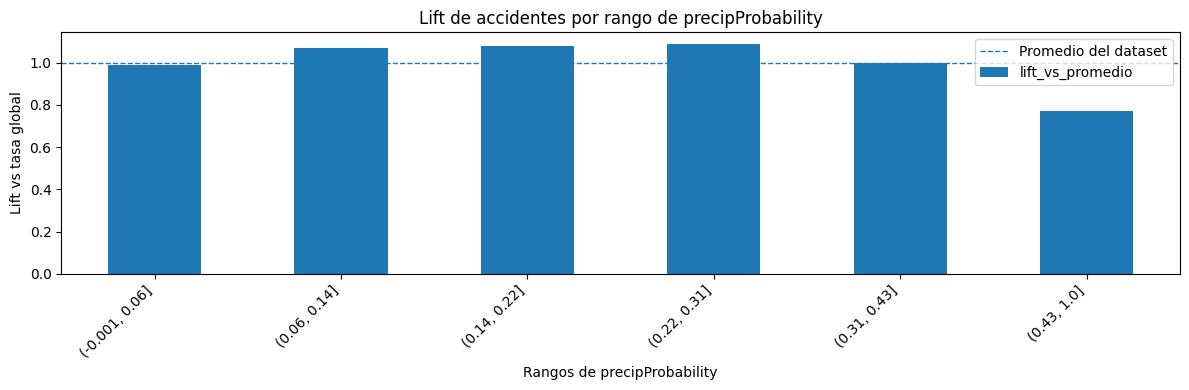


VARIABLE: windSpeed


,rango_windSpeed,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(-0.001, 0.04]",748988,7237,0.009662,741751,0.9662,96.62,0.64,10.07
1,"(0.04, 0.64]",752692,9477,0.012591,743215,1.2591,125.91,0.83,10.12
2,"(0.64, 0.9]",779924,7699,0.009871,772225,0.9871,98.71,0.65,10.49
3,"(0.9, 1.1]",715320,8049,0.011252,707271,1.1252,112.52,0.74,9.62
4,"(1.1, 1.33]",747445,9547,0.012773,737898,1.2773,127.73,0.84,10.05
5,"(1.33, 1.5]",743788,9439,0.012690,734349,1.2690,126.90,0.84,10.00
6,"(1.5, 1.82]",719966,11718,0.016276,708248,1.6276,162.76,1.08,9.68
7,"(1.82, 2.24]",747966,13824,0.018482,734142,1.8482,184.82,1.22,10.06
8,"(2.24, 3.03]",741470,16740,0.022577,724730,2.2577,225.77,1.49,9.97
9,"(3.03, 15.26]",738629,18845,0.025513,719784,2.5513,255.13,1.69,9.93


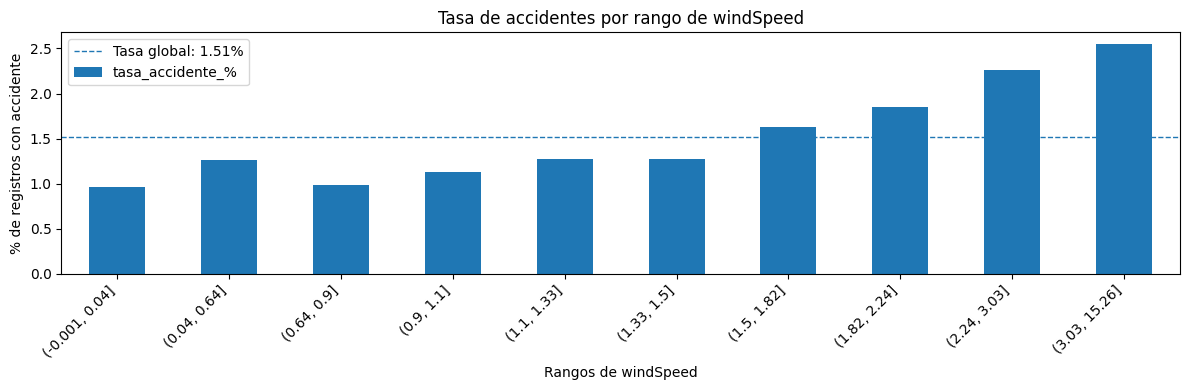

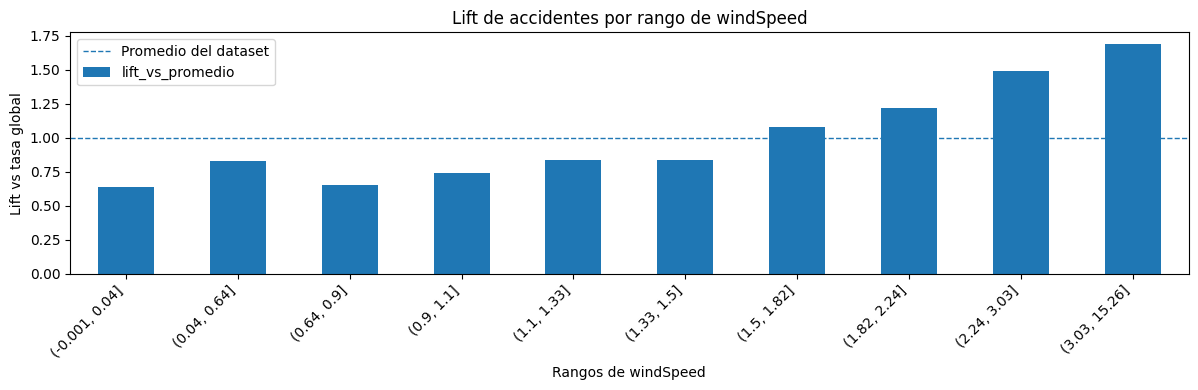


VARIABLE: windBearing


,rango_windBearing,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(-0.001, 30.0]",758489,14866,0.019599,743623,1.9599,195.99,1.29,10.20
1,"(30.0, 60.0]",739335,12856,0.017389,726479,1.7389,173.89,1.15,9.94
2,"(60.0, 78.0]",767066,10499,0.013687,756567,1.3687,136.87,0.90,10.32
3,"(78.0, 90.0]",1946726,21984,0.011293,1924742,1.1293,112.93,0.75,26.18
4,"(90.0, 95.0]",284998,3775,0.013246,281223,1.3246,132.46,0.87,3.83
5,"(95.0, 112.0]",730439,10574,0.014476,719865,1.4476,144.76,0.96,9.82
6,"(112.0, 140.0]",733766,11333,0.015445,722433,1.5445,154.45,1.02,9.87
7,"(140.0, 210.0]",734580,13479,0.018349,721101,1.8349,183.49,1.21,9.88
8,"(210.0, 359.0]",740789,13209,0.017831,727580,1.7831,178.31,1.18,9.96


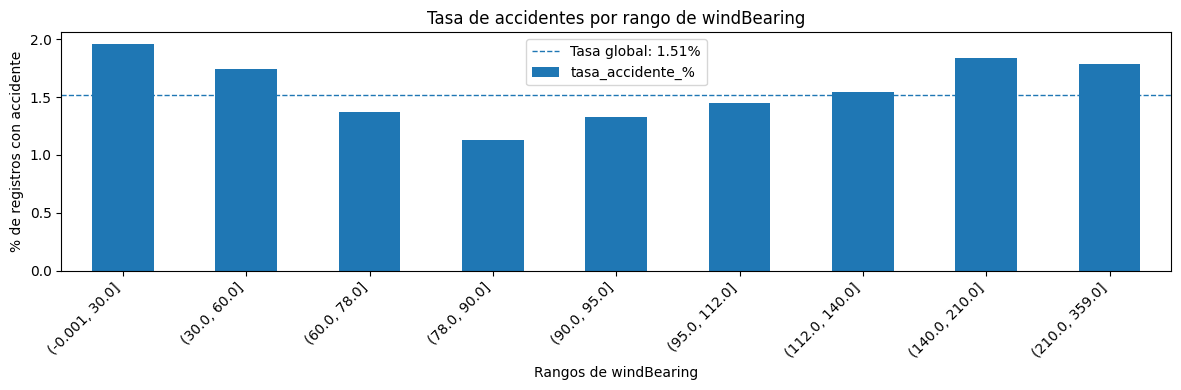

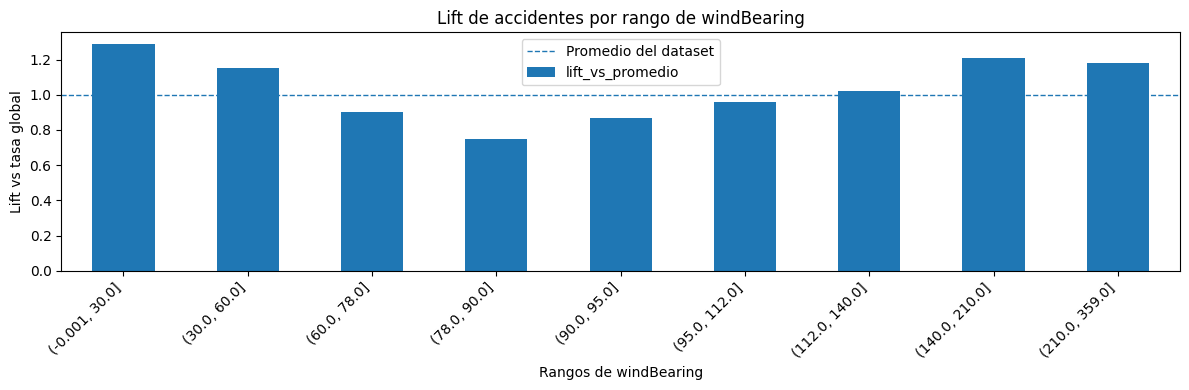


VARIABLE: cloudCover


,rango_cloudCover,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(-0.001, 0.44]",1476482,21080,0.014277,1455402,1.4277,142.77,0.94,19.86
1,"(0.44, 0.45]",62495,1721,0.027538,60774,2.7538,275.38,1.82,0.84
2,"(0.45, 0.69]",699819,12043,0.017209,687776,1.7209,172.09,1.14,9.41
3,"(0.69, 0.75]",1958013,30692,0.015675,1927321,1.5675,156.75,1.04,26.33
4,"(0.75, 0.79]",320751,5879,0.018329,314872,1.8329,183.29,1.21,4.31
5,"(0.79, 0.87]",698142,12199,0.017474,685943,1.7474,174.74,1.15,9.39
6,"(0.87, 0.94]",867616,12755,0.014701,854861,1.4701,147.01,0.97,11.67
7,"(0.94, 0.98]",776957,9394,0.012091,767563,1.2091,120.91,0.80,10.45
8,"(0.98, 1.0]",575913,6812,0.011828,569101,1.1828,118.28,0.78,7.74


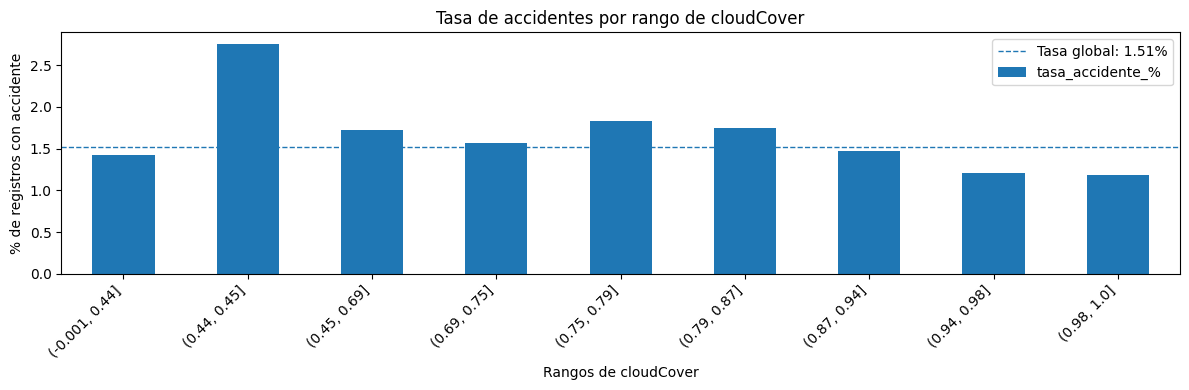

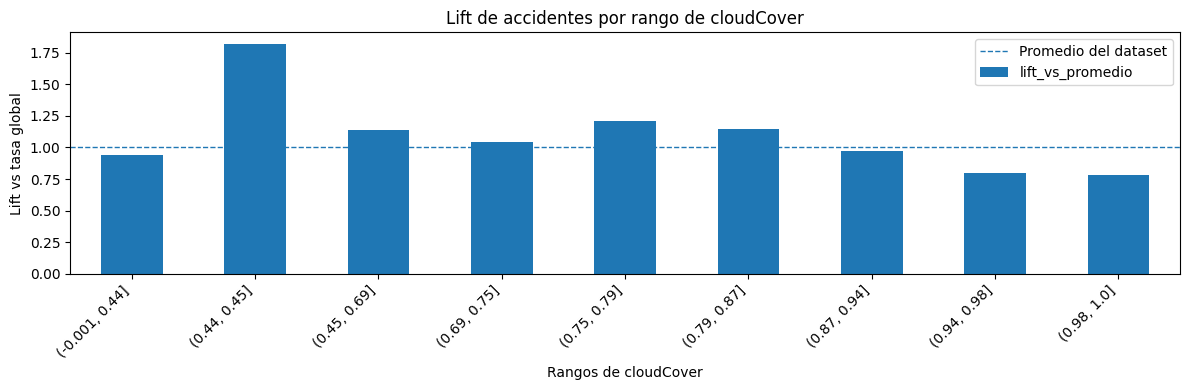


VARIABLE: uvIndex


,rango_uvIndex,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(-0.001, 1.0]",4719713,56371,0.011944,4663342,1.1944,119.44,0.79,63.47
1,"(1.0, 3.0]",626102,12795,0.020436,613307,2.0436,204.36,1.35,8.42
2,"(3.0, 5.0]",710276,14066,0.019804,696210,1.9804,198.04,1.31,9.55
3,"(5.0, 7.0]",958276,20088,0.020963,938188,2.0963,209.63,1.38,12.89
4,"(7.0, 14.0]",421821,9255,0.021941,412566,2.1941,219.41,1.45,5.67


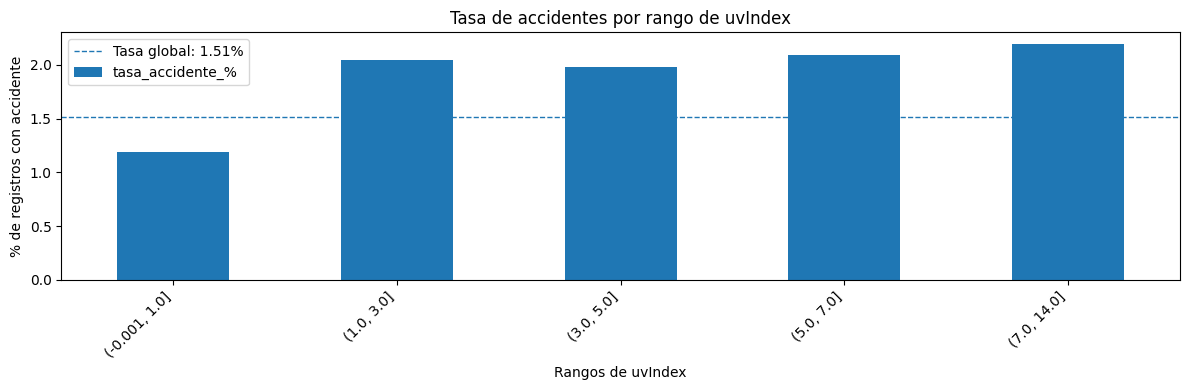

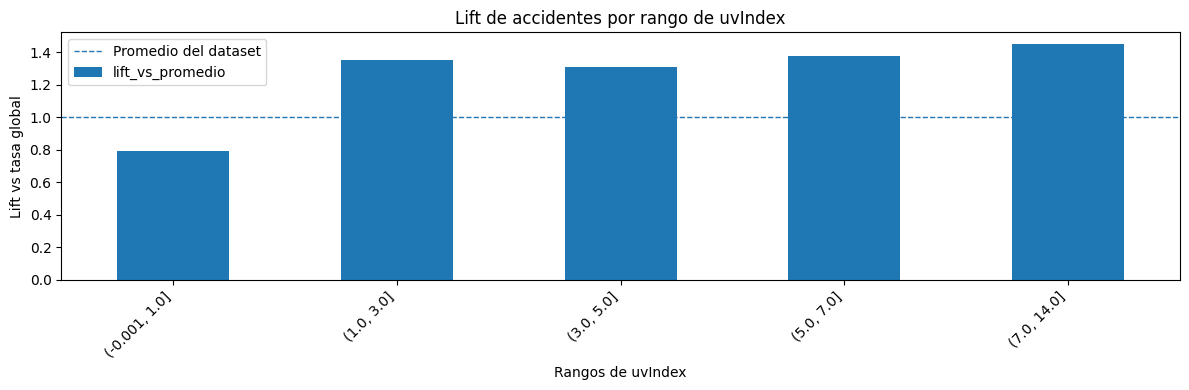


VARIABLE: visibility


,rango_visibility,total_registros,accidentes,tasa_accidente,no_accidentes,tasa_accidente_%,accidentes_por_10000,lift_vs_promedio,porcentaje_datos
0,"(0.098, 7.308]",743767,6751,0.009077,737016,0.9077,90.77,0.60,10.00
1,"(7.308, 9.495]",743629,10584,0.014233,733045,1.4233,142.33,0.94,10.00
2,"(9.495, 10.003]",2688117,46196,0.017185,2641921,1.7185,171.85,1.14,36.15
3,"(10.003, 11.525]",286287,5531,0.019320,280756,1.9320,193.20,1.28,3.85
4,"(11.525, 14.318]",743709,13171,0.017710,730538,1.7710,177.10,1.17,10.00
5,"(14.318, 16.093]",2230679,30342,0.013602,2200337,1.3602,136.02,0.90,30.00


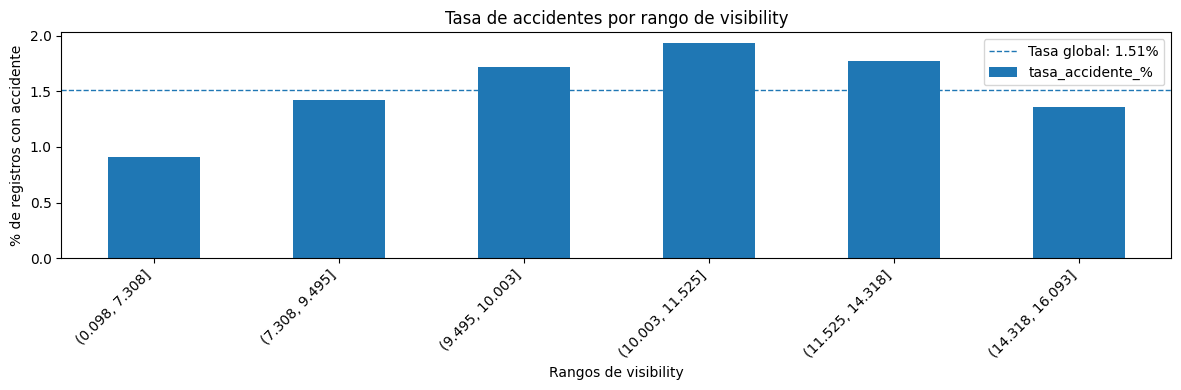

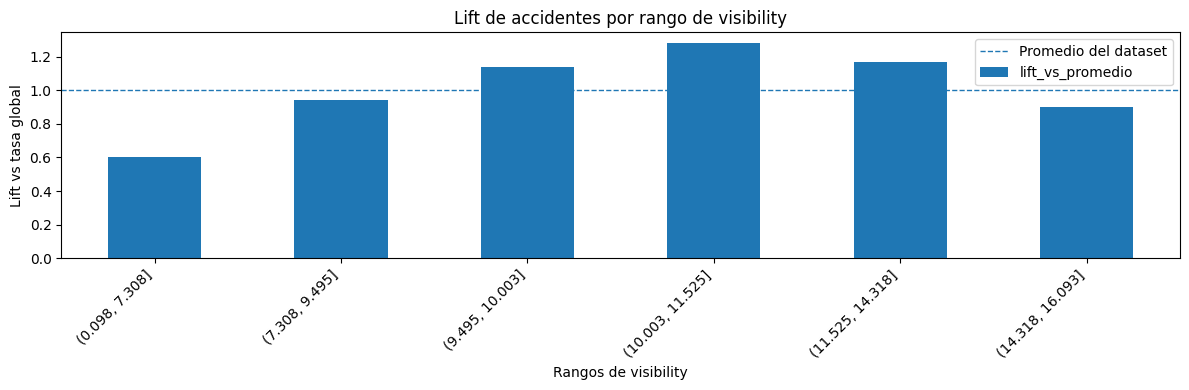

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# TASA DE ACCIDENTE POR RANGO CLIMÁTICO
# =========================================================

# Usa aquí el nombre de tu dataframe final
# Debe ser el resultado de clima LEFT JOIN accidentes
df_eda = df_modelo.copy()

TARGET = "target"

VARS_CLIMA = [
    "temperature",
    "apparentTemperature",
    "dewPoint",
    "humidity",
    "precipIntensity",
    "precipProbability",
    "windSpeed",
    "windBearing",
    "cloudCover",
    "uvIndex",
    "visibility"
]

# Quedarse solo con variables que existan y sean numéricas
variables_clima = [
    col for col in VARS_CLIMA
    if col in df_eda.columns and pd.api.types.is_numeric_dtype(df_eda[col])
]

print("Variables climáticas encontradas:")
print(variables_clima)

# Tasa global de accidentes
tasa_global = df_eda[TARGET].mean()

print("\n" + "="*70)
print("TASA GLOBAL DE ACCIDENTES")
print("="*70)
print(f"Tasa global: {tasa_global*100:.4f}%")
print(f"Accidentes por cada 10.000 registros: {tasa_global*10000:.2f}")

# Guardar resultados de cada variable
resultados_rangos = {}

# Número de rangos
Q = 10

for col in variables_clima:
    
    print("\n" + "="*80)
    print(f"VARIABLE: {col}")
    print("="*80)
    
    rango_col = f"rango_{col}"
    
    # Crear rangos por cuantiles
    # Solo se calculan sobre valores no nulos
    df_eda[rango_col] = pd.qcut(
        df_eda[col],
        q=Q,
        duplicates="drop"
    )
    
    # Resumen por rango
    resumen = (
        df_eda
        .groupby(rango_col, observed=True)
        .agg(
            total_registros=(TARGET, "size"),
            accidentes=(TARGET, "sum"),
            tasa_accidente=(TARGET, "mean")
        )
        .reset_index()
    )
    
    # Métricas interpretables
    resumen["no_accidentes"] = resumen["total_registros"] - resumen["accidentes"]
    resumen["tasa_accidente_%"] = (resumen["tasa_accidente"] * 100).round(4)
    resumen["accidentes_por_10000"] = (resumen["tasa_accidente"] * 10000).round(2)
    resumen["lift_vs_promedio"] = (resumen["tasa_accidente"] / tasa_global).round(2)
    resumen["porcentaje_datos"] = (
        resumen["total_registros"] / len(df_eda) * 100
    ).round(2)
    
    # Guardar resultado
    resultados_rangos[col] = resumen
    
    # Mostrar tabla
    display(resumen)
    
    # Gráfico: tasa de accidente por rango
    ax = resumen.plot(
        x=rango_col,
        y="tasa_accidente_%",
        kind="bar",
        figsize=(12, 4),
        legend=False,
        title=f"Tasa de accidentes por rango de {col}"
    )
    
    ax.axhline(
        tasa_global * 100,
        linestyle="--",
        linewidth=1,
        label=f"Tasa global: {tasa_global*100:.2f}%"
    )
    
    ax.set_ylabel("% de registros con accidente")
    ax.set_xlabel(f"Rangos de {col}")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    
    # Gráfico: lift
    ax = resumen.plot(
        x=rango_col,
        y="lift_vs_promedio",
        kind="bar",
        figsize=(12, 4),
        legend=False,
        title=f"Lift de accidentes por rango de {col}"
    )
    
    ax.axhline(
        1,
        linestyle="--",
        linewidth=1,
        label="Promedio del dataset"
    )
    
    ax.set_ylabel("Lift vs tasa global")
    ax.set_xlabel(f"Rangos de {col}")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

| Variable | Patrón principal | Interpretación posible |
|---|---|---|
| **temperature** | A mayor temperatura, mayor tasa de accidentes. | Es una de las señales más claras. Los rangos altos de temperatura tienen tasas por encima del promedio y lift alto. Puede estar relacionado con horas del día de mayor movilidad. |
| **humidity** | A mayor humedad, menor tasa de accidentes. | Patrón inverso fuerte. La humedad baja tiene más accidentes que el promedio; la humedad alta tiene menos. Puede estar mezclado con hora, lluvia o menor movilidad. |
| **dewPoint** | Tiende a subir levemente en rangos altos. | Señal moderada. El punto de rocío alto parece asociarse con tasas algo mayores, pero no tan fuerte como la temperatura. |
| **precipIntensity** | Casi plana, muy cerca del promedio. | La intensidad de lluvia no parece separar mucho los casos con y sin accidente. Su señal individual parece débil. |
| **precipProbability** | Casi plana; el rango más alto baja. | La probabilidad de lluvia no muestra una relación creciente clara. En probabilidad alta incluso baja la tasa, lo que puede indicar menor movilidad cuando hay mayor probabilidad de lluvia. |
| **windSpeed** | A mayor velocidad del viento, mayor tasa de accidentes. | Señal bastante interesante. Los rangos altos de viento superan la tasa global y tienen lift alto. |
| **windBearing** | Cambia por rangos, pero sin patrón simple. | Puede tener algo de señal, pero como representa dirección del viento debe tratarse como variable circular, idealmente con seno y coseno. |
| **cloudCover** | Patrón no lineal; pico en nubosidad media. | Algunos rangos medios tienen tasas altas, pero la nubosidad muy alta baja. Conviene revisar si hay muchos valores repetidos en ciertos rangos. |
| **uvIndex** | Valores altos tienen mayor tasa de accidentes. | Parece útil, pero probablemente está capturando indirectamente la hora del día: el UV alto ocurre de día, cuando suele haber mayor movilidad. |

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN
# =========================================================

df_eda = df_modelo.copy()
TARGET = "target"

VARS_CLIMA = [
    "temperature",
    "apparentTemperature",
    "dewPoint",
    "humidity",
    "precipIntensity",
    "precipProbability",
    "windSpeed",
    "windBearing",
    "cloudCover",
    "uvIndex",
    "visibility"
]

variables_clima = [
    col for col in VARS_CLIMA
    if col in df_eda.columns and pd.api.types.is_numeric_dtype(df_eda[col])
]

df_eda[TARGET] = df_eda[TARGET].astype(int)

print("Variables climáticas encontradas:")
print(variables_clima)

# =========================================================
# TABLA COMPARATIVA TARGET 0 VS TARGET 1
# =========================================================

resumen = []

for col in variables_clima:
    grupo_0 = df_eda.loc[df_eda[TARGET] == 0, col]
    grupo_1 = df_eda.loc[df_eda[TARGET] == 1, col]
    
    resumen.append({
        "variable": col,
        "media_target_0": grupo_0.mean(),
        "media_target_1": grupo_1.mean(),
        "dif_media_1_menos_0": grupo_1.mean() - grupo_0.mean(),
        "mediana_target_0": grupo_0.median(),
        "mediana_target_1": grupo_1.median(),
        "dif_mediana_1_menos_0": grupo_1.median() - grupo_0.median(),
        "p25_target_0": grupo_0.quantile(0.25),
        "p25_target_1": grupo_1.quantile(0.25),
        "p75_target_0": grupo_0.quantile(0.75),
        "p75_target_1": grupo_1.quantile(0.75),
        "nulos_%_target_0": grupo_0.isna().mean() * 100,
        "nulos_%_target_1": grupo_1.isna().mean() * 100
    })

resumen_clima_target = pd.DataFrame(resumen)

# Redondear para mejor visualización
resumen_clima_target = resumen_clima_target.round(4)

display(resumen_clima_target)

Variables climáticas encontradas:
['temperature', 'dewPoint', 'humidity', 'precipIntensity', 'precipProbability', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility']


,variable,media_target_0,media_target_1,dif_media_1_menos_0,mediana_target_0,mediana_target_1,dif_mediana_1_menos_0,p25_target_0,p25_target_1,p75_target_0,p75_target_1,nulos_%_target_0,nulos_%_target_1
0,temperature,19.5564,21.4564,1.9000,18.5200,21.2600,2.7400,16.780,18.350,22.3600,24.4100,0.0,0.0
1,dewPoint,14.3184,14.7152,0.3968,14.3900,14.8700,0.4800,12.940,13.360,15.7900,16.2300,0.0,0.0
2,humidity,0.7373,0.6762,-0.0611,0.7400,0.6900,-0.0500,0.650,0.560,0.8500,0.8000,0.0,0.0
3,precipIntensity,0.4760,0.4960,0.0200,0.0302,0.0361,0.0059,0.000,0.000,0.6052,0.6654,0.0,0.0
4,precipProbability,0.1598,0.1474,-0.0124,0.0600,0.0700,0.0100,0.000,0.000,0.2600,0.2500,0.0,0.0
5,windSpeed,1.5091,1.8828,0.3736,1.3200,1.6300,0.3100,0.790,1.020,2.0500,2.5600,0.0,0.0
6,windBearing,108.0503,110.7173,2.6670,90.0000,90.0000,0.0000,71.000,61.000,120.0000,135.0000,0.0,0.0
7,cloudCover,0.7299,0.7173,-0.0126,0.7500,0.7500,0.0000,0.570,0.560,0.9100,0.8800,0.0,0.0
8,uvIndex,1.9958,2.7880,0.7922,0.0000,1.0000,1.0000,0.000,0.000,4.0000,6.0000,0.0,0.0
9,visibility,11.4612,11.5398,0.0786,10.0030,10.0030,0.0000,10.003,10.003,15.4200,14.7515,0.0,0.0


| Variable | Qué muestra la tabla | Interpretación |
|---|---|---|
| **temperature** | Sube de **19.56** en `target = 0` a **21.46** en `target = 1`. La mediana también sube bastante: **18.52 → 21.26**. | Es una de las diferencias más claras. Los accidentes parecen asociarse con temperaturas más altas. |
| **dewPoint** | Sube levemente: **14.32 → 14.72**. | Hay una diferencia moderada, pero no tan fuerte como temperatura. |
| **humidity** | Baja de **0.737** a **0.676**. | En los accidentes hay menor humedad relativa. Esto coincide con las gráficas: humedad alta tenía menor tasa de accidentes. |
| **precipIntensity** | Muy parecido: **0.476 → 0.496**. | La intensidad de lluvia no cambia mucho entre positivos y negativos. Señal débil. |
| **precipProbability** | Baja levemente en promedio: **0.1598 → 0.1474**, aunque la mediana sube un poco. | No hay un patrón fuerte ni claro. Parece débil como variable individual. |
| **windSpeed** | Sube de **1.51** a **1.88**. La mediana sube de **1.32 → 1.63**. | Diferencia importante. Los accidentes parecen ocurrir con vientos más altos. |
| **windBearing** | Media algo mayor, pero mediana igual: **90 → 90**. | No se interpreta fácil como número normal porque es dirección del viento. Mejor transformarla con seno/coseno. |
| **cloudCover** | Muy parecido: **0.7299 → 0.7173**. | No parece separar mucho los casos con y sin accidente. |
| **uvIndex** | Sube bastante: **1.99 → 2.79**. La mediana pasa de **0 → 1** y el p75 de **4 → 6**. | Señal clara, pero probablemente está capturando hora del día: más UV = más horas diurnas = más movilidad. |
| **visibility** | Muy parecido: **11.46 → 11.54**. Mediana igual. | No parece haber una diferencia fuerte entre accidentes y no accidentes. |

In [12]:
# Variables climáticas candidatas a eliminar
variables_eliminar = [
    "precipIntensity",
    "precipProbability",
    "visibility",
    "cloudCover"
]

# Eliminar solo si existen en el dataframe
df_modelo = df_modelo.drop(columns=variables_eliminar, errors="ignore")

print("Variables eliminadas:")
print(variables_eliminar)

print("\nColumnas restantes:")
print(df_modelo.columns.tolist())

Variables eliminadas:
['precipIntensity', 'precipProbability', 'visibility', 'cloudCover']

Columnas restantes:
['TW', 'BARRIO', 'summary', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'uvIndex', 'target']


| Variable | Decisión | Justificación |
|---|---|---|
| **precipIntensity** | Candidata a eliminar | La tasa queda casi igual al promedio. No parece separar bien `target = 0` y `target = 1`. |
| **precipProbability** | Candidata a eliminar | También tiene señal débil. Incluso el rango más alto baja la tasa. No muestra una relación clara. |
| **visibility** | Candidata a eliminar | La media y la mediana son casi iguales entre `target = 0` y `target = 1`. La relación por rangos no es muy clara. |
| **cloudCover** | No eliminar de una | La media cambia poco, pero por rangos tuvo un pico interesante. Puede tener relación no lineal. Se podría dejar si se usan modelos como Random Forest o Gradient Boosting. |